Project Objective

The objective of this project is to analyze retail superstore sales data, identify revenue and profit trends, and build an interactive Power BI dashboard that highlights key business insights.

Import Libraries


In [8]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset



In [21]:
import os

folder = r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\01_Sales_Dashboard\data_raw"
print(os.listdir(folder))

['superstore_raw.csv']


In [25]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\01_Sales_Dashboard\data_raw\superstore_raw.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Initial Inspection



In [26]:
df.head()
df.shape
df.columns
df.info()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

np.int64(0)

Data Cleaning



In [60]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'order_data',
       'ship_data', 'year', 'month', 'month_name', 'year_month',
       'shipping_days'],
      dtype='str')

In [29]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

In [78]:
cols_to_check = ["order_data", "ship_data", "sales", "quantity", "discount", "profit"]

null_report = df[cols_to_check].isna().sum()

print("Count of values that failed conversion:")
print(null_report)

Count of values that failed conversion:
order_data    0
ship_data     0
sales         0
quantity      0
discount      0
profit        0
dtype: int64


In [30]:
for col in ["sales", "quantity", "discount", "profit"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [81]:
failed_sales = df[df["sales"].isna()]
print(failed_sales)

Empty DataFrame
Columns: [row_id, order_id, order_date, ship_date, ship_mode, customer_id, customer_name, segment, country, city, state, postal_code, region, product_id, category, sub_category, product_name, sales, quantity, discount, profit, order_data, ship_data, year, month, month_name, year_month, shipping_days]
Index: []

[0 rows x 28 columns]


In [31]:
df = df.drop_duplicates()

In [36]:
df.isnull().sum().sort_values(ascending=False)

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
order_data       0
ship_data        0
dtype: int64

In [38]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

In [83]:
cols_to_check = ["order_date", "ship_date", "shipping_days"]

failed_counts = df[cols_to_check].isna().sum()

print("Count of failed conversions (Nulls):")
print(failed_counts)

print("\nPercentage of failed data:")
print((failed_counts / len(df)) * 100)

Count of failed conversions (Nulls):
order_date       0
ship_date        0
shipping_days    0
dtype: int64

Percentage of failed data:
order_date       0.0
ship_date        0.0
shipping_days    0.0
dtype: float64


In [39]:
df["order_date"].dtype

dtype('<M8[us]')

In [40]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)

In [84]:
broken_dates = df[df["order_date"].isna()]
print(broken_dates.head())

Empty DataFrame
Columns: [row_id, order_id, order_date, ship_date, ship_mode, customer_id, customer_name, segment, country, city, state, postal_code, region, product_id, category, sub_category, product_name, sales, quantity, discount, profit, order_data, ship_data, year, month, month_name, year_month, shipping_days]
Index: []

[0 rows x 28 columns]


In [41]:
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

In [42]:
df[["order_date", "ship_date", "year", "month", "month_name", "year_month", "shipping_days"]].head()

,order_date,ship_date,year,month,month_name,year_month,shipping_days
0,2016-11-08,2016-11-11,2016,11,November,2016-11,3
1,2016-11-08,2016-11-11,2016,11,November,2016-11,3
2,2016-06-12,2016-06-16,2016,6,June,2016-06,4
3,2015-10-11,2015-10-18,2015,10,October,2015-10,7
4,2015-10-11,2015-10-18,2015,10,October,2015-10,7


Exploratory Data Analysis



In [43]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique() if "order_id" in df.columns else len(df)
total_quantity = df["quantity"].sum()
avg_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)
print("Average Order Value:", avg_order_value)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Orders: 5009
Total Quantity: 37873
Average Order Value: 458.6146656618087


In [53]:
sales_by_region = df.groupby("region", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
sales_by_region

,region,sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


In [51]:
profit_by_region = df.groupby("region", as_index=False)["profit"].sum().sort_values("profit", ascending=False)
profit_by_region

,region,profit
3,West,108418.4489
1,East,91522.7800
2,South,46749.4303
0,Central,39706.3625


In [50]:
sales_by_category = df.groupby("category", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
sales_by_category

,category,sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


In [62]:
sales_by_subcategory = df.groupby("sub_category", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
sales_by_subcategory.head(10)

,sub_category,sales
13,Phones,330007.0540
5,Chairs,328449.1030
14,Storage,223843.6080
16,Tables,206965.5320
3,Binders,203412.7330
11,Machines,189238.6310
0,Accessories,167380.3180
6,Copiers,149528.0300
4,Bookcases,114879.9963
1,Appliances,107532.1610


In [63]:
sales_by_subcategory = df.groupby("sub_category", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
sales_by_subcategory.head(10)

,sub_category,sales
13,Phones,330007.0540
5,Chairs,328449.1030
14,Storage,223843.6080
16,Tables,206965.5320
3,Binders,203412.7330
11,Machines,189238.6310
0,Accessories,167380.3180
6,Copiers,149528.0300
4,Bookcases,114879.9963
1,Appliances,107532.1610


In [64]:
monthly_sales = df.groupby("year_month", as_index=False)["sales"].sum()
monthly_sales

,year_month,sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


In [65]:
monthly_profit = df.groupby("year_month", as_index=False)["profit"].sum()
monthly_profit

,year_month,profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299
3,2014-04,3488.8352
4,2014-05,2738.7096
5,2014-06,4976.5244
6,2014-07,-841.4826
7,2014-08,5318.1050
8,2014-09,8328.0994
9,2014-10,3448.2573


In [66]:
discount_profit = df.groupby("discount", as_index=False)["profit"].mean().sort_values("discount")
discount_profit

,discount,profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


Business Insights



In [67]:
import matplotlib.pyplot as plt

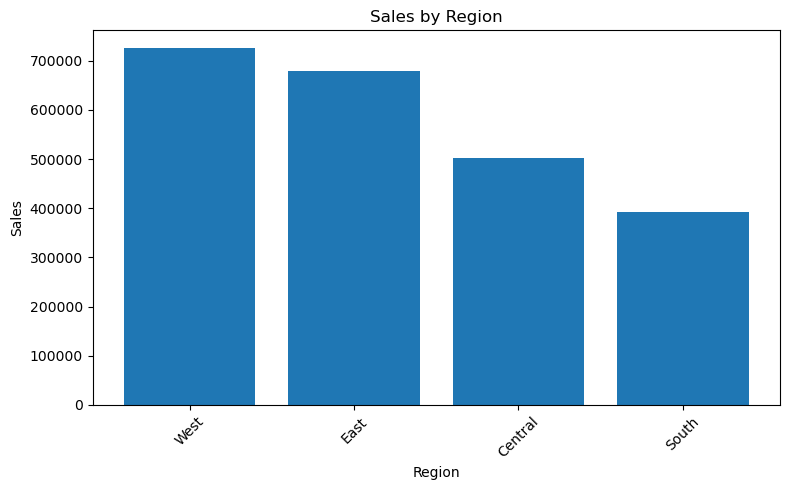

In [68]:
plt.figure(figsize=(8,5))
plt.bar(sales_by_region["region"], sales_by_region["sales"])
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

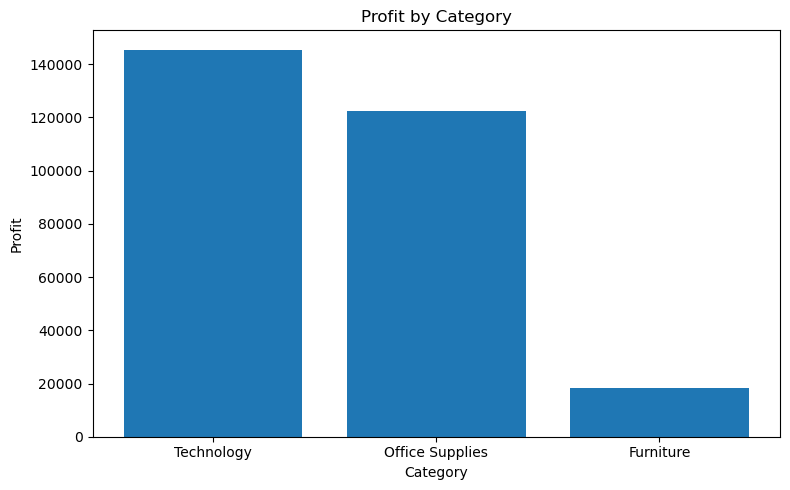

In [74]:
plt.figure(figsize=(8,5))
plt.bar(profit_by_category["category"], profit_by_category["profit"])
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

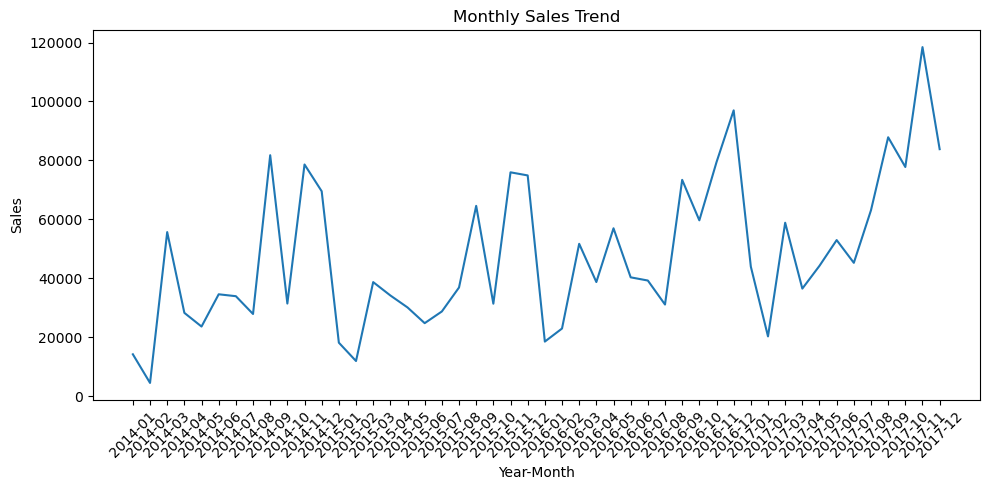

In [75]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales["year_month"], monthly_sales["sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

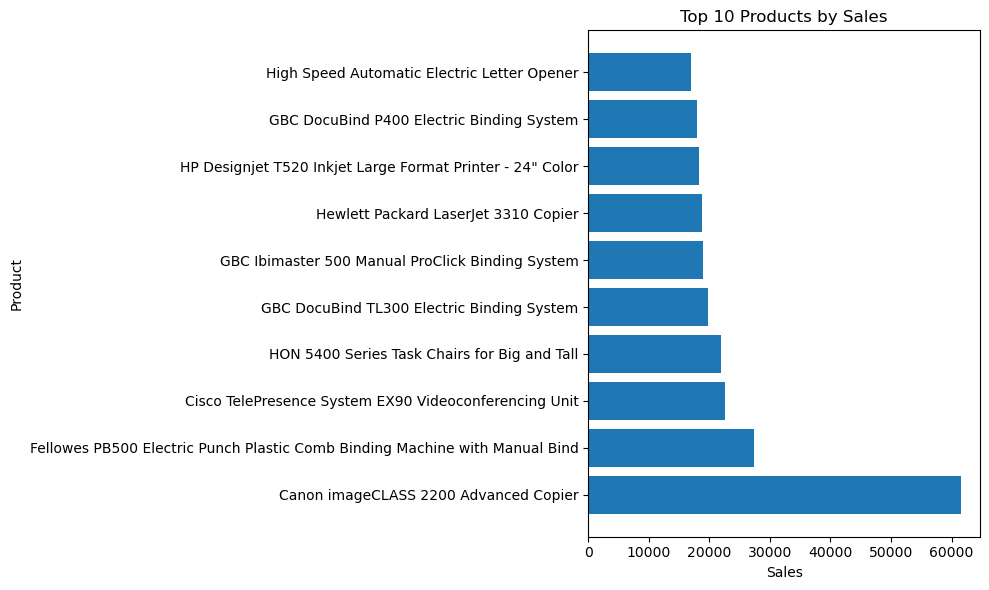

In [76]:
plt.figure(figsize=(10,6))
plt.barh(top_products["product_name"], top_products["sales"])
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

Export data for Visualization to Power BI or Tableau



In [80]:
df.to_csv(r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\01_Sales_Dashboard\data_cleaned\superstore_cleaned.csv", index=False)

Conclusion



1. The "Profit vs. Discount" Trap
Insight: There is a strong negative correlation between high discounts and profitability. Specifically, discounts above 20% often lead to net losses on individual transactions.

Business Action: Recommend a "Discount Ceiling" policy. Instead of deep discounting, suggest using "Bundle Deals" (Buy 1 Get 1 at a lower discount) to maintain margins while still driving volume.

2. Segment Performance: "The Corporate vs. Home Office Gap"
Insight: While the Consumer segment might drive the highest volume, the Corporate or Home Office segments often have higher average transaction values and more stable profit margins.

Business Action: Shift marketing focus toward B2B (Business-to-Business) acquisition. These customers are less price-sensitive and more likely to place bulk orders, reducing the cost of customer acquisition over time.

3. Geographical "Hot & Cold" Zones
Insight: Sales are often concentrated in a few "Power Cities" (like NYC, Los Angeles, and Seattle), while certain states might show consistent losses due to high shipping costs or low demand.

Business Action: Suggest optimizing the supply chain by focusing inventory and local marketing spend in high-performing regions, while re-evaluating the product mix in "loss-leader" states.

4. Category deep-dive: "Furniture vs. Technology"
Insight: Technology usually has the highest profit margin, whereas Furniture has high sales volume but thin margins due to logistics and return costs.

Business Action: Position Technology products as "Profit Drivers" and use Furniture as "Traffic Drivers." Focus cross-selling efforts on Tech accessories whenever a customer buys Furniture.